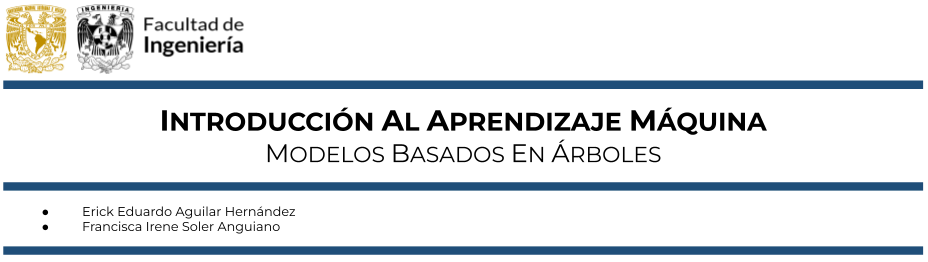

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 7.1.1 — Implementación: bagging en clasificación
___

### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para estudiar un modelo de clasificación construido mediante **bagging**. Además de las herramientas usuales para manipular datos y producir gráficas, se cargan métricas de clasificación y utilidades de `scikit-learn` que permiten comparar el desempeño en entrenamiento y prueba. Esta preparación deja listo el entorno para analizar cómo un ensamble de árboles puede reducir la variabilidad de un árbol individual.


In [1]:
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

### Carga del conjunto Breast Cancer

En este notebook estudiaremos la aplicación de Bagging para un problema de clasificación utilizando el conjunto de datos Breast Cancer Wisconsin guardado localmente en el directorio `datos`. El objetivo consiste en clasificar tumores como benignos o malignos a partir de diferentes características obtenidas mediante imágenes digitalizadas. Al leer el archivo CSV local, el notebook deja de depender de funciones de descarga o carga externa y se vuelve más reproducible dentro del repositorio.


In [2]:
data_paths = [Path("datos") / "breast-cancer.csv", Path("..") / "datos" / "breast-cancer.csv"]
data_path = next(path for path in data_paths if path.exists())
cancer_data_df = pd.read_csv(data_path)
feature_names = cancer_data_df.drop(columns="diagnosis").columns.tolist()
cancer_data_df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


### Descripción de las variables del conjunto Breast Cancer

El conjunto de datos Breast Cancer Wisconsin Diagnostic contiene 30 variables predictoras, todas obtenidas a partir del análisis digital de imágenes de una aspiración con aguja fina (Fine Needle Aspiration, FNA) de una masa mamaria. De estas se miden de 3 carcateristicas básicas:

| Característica | Descripción |
|----------------|-------------|
| **Radius (Radio)** | Distancia promedio desde el centro del núcleo hasta su borde. Mide el tamaño del núcleo celular. |
| **Texture (Textura)** | Variación en la intensidad de los niveles de gris dentro del núcleo. Describe la heterogeneidad de la imagen. |
| **Perimeter (Perímetro)** | Longitud del contorno del núcleo celular. |
| **Area (Área)** | Superficie ocupada por el núcleo celular. |
| **Smoothness (Suavidad)** | Mide qué tan suave o regular es el contorno del núcleo, cuantificando pequeñas variaciones locales del radio. |
| **Compactness (Compacidad)** | Mide qué tan compacto es el núcleo. Se calcula como $begin:math:text$\(\\text\{Perímetro\}\^2\/\\text\{Área\}\) \- 1$end:math:text$; valores altos indican formas más irregulares. |
| **Concavity (Concavidad)** | Cuantifica la profundidad o severidad de las regiones cóncavas presentes en el contorno del núcleo. |
| **Concave Points (Puntos cóncavos)** | Número de puntos cóncavos presentes en el contorno del núcleo celular. |
| **Symmetry (Simetría)** | Mide el grado de simetría de la forma del núcleo celular. |
| **Fractal Dimension (Dimensión fractal)** | Cuantifica la complejidad geométrica del contorno del núcleo; valores mayores indican bordes más irregulares. |

Para cada una de ellas (radio, textura, perímetro, etc.) se calculan tres medidas:

* Mean: promedio de la característica en todos los núcleos analizados.
* Error: error estándar, que mide la variabilidad de dicha característica.
* Worst: promedio de los tres valores más grandes de esa característica, representando el comportamiento más extremo observado en la muestra.

De esta forma, el conjunto de datos contiene:

* 10 características morfológicas básicas.
* 3 estadísticas para cada característica (mean, error y worst).

En total:

10 x 3 = 30

variables predictoras.



### Distribución de la variable respuesta

Antes de ajustar un clasificador conviene revisar cuántas observaciones hay en cada clase. En problemas de clasificación, una distribución desbalanceada puede hacer que una métrica agregada como la exactitud sea engañosa. Por eso se muestran tanto las frecuencias absolutas como las proporciones de la variable `diagnosis`, lo cual ayuda a interpretar después los resultados en entrenamiento y prueba.


In [3]:
print(cancer_data_df["diagnosis"].value_counts())
print(cancer_data_df["diagnosis"].value_counts()/len(cancer_data_df))

diagnosis
1    357
0    212
Name: count, dtype: int64
diagnosis
1    0.627417
0    0.372583
Name: count, dtype: float64


### Separación estratificada en entrenamiento y prueba

El conjunto se divide en datos de entrenamiento y datos de prueba. La muestra de entrenamiento se utiliza para ajustar los árboles del ensamble, mientras que la muestra de prueba se reserva para medir desempeño fuera de muestra. La opción `stratify` conserva la proporción original de clases en ambos subconjuntos, lo que es especialmente útil en clasificación porque evita que una partición quede artificialmente cargada hacia una de las clases.


In [4]:
from sklearn.model_selection import train_test_split

X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    cancer_data_df[feature_names],
    cancer_data_df["diagnosis"],
    test_size=0.25,
    stratify=cancer_data_df["diagnosis"],
    random_state=123)

### Ajuste de bagging con distintos números de árboles

Bagging construye muchos árboles sobre muestras bootstrap del conjunto de entrenamiento y combina sus predicciones. La idea central es reducir la variabilidad de un árbol individual: cada árbol puede cambiar bastante ante pequeñas variaciones de los datos, pero el promedio o voto de muchos árboles suele ser más estable. En esta celda se ajustan ensambles con diferentes valores de `n_estimators` y se guarda la exactitud obtenida en entrenamiento y prueba para estudiar cómo cambia el desempeño conforme aumenta el número de árboles.


In [5]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

n_estimators_list = [1,3,5,8,10,15,20,50,100,200]

accuracy_train = []
accuracy_test = []

for n_estimators in n_estimators_list:

    cancer_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=43),
        n_estimators=n_estimators,
        bootstrap=True,
        random_state=43,
        n_jobs=-1).fit(X_train_cancer, y_train_cancer)
    
    y_train_pred = cancer_model.predict(X_train_cancer)
    y_test_pred = cancer_model.predict(X_test_cancer)
    accuracy_train.append(
        accuracy_score(y_train_cancer, y_train_pred)
    )
    accuracy_test.append(
        accuracy_score(y_test_cancer, y_test_pred)
    )

resultados = pd.DataFrame({
    "Número de árboles": n_estimators_list,
    "Accuracy entrenamiento": accuracy_train,
    "Accuracy prueba": accuracy_test
})
resultados

,Número de árboles,Accuracy entrenamiento,Accuracy prueba
0,1,0.976526,0.951049
1,3,0.983568,0.951049
2,5,0.990610,0.944056
3,8,0.997653,0.951049
4,10,0.997653,0.965035
5,15,0.995305,0.965035
6,20,0.995305,0.958042
7,50,1.000000,0.958042
8,100,0.997653,0.958042
9,200,1.000000,0.958042


### Evolución de la exactitud al aumentar el número de árboles

La gráfica compara la exactitud de entrenamiento y prueba para cada valor de `n_estimators`. Si la línea de entrenamiento es muy alta y la de prueba queda claramente por debajo, puede haber sobreajuste. Al aumentar el número de árboles, el bagging suele estabilizar el desempeño fuera de muestra, aunque después de cierto punto las mejoras pueden ser pequeñas. El eje vertical inicia cerca de cero para que la separación entre ambas curvas se interprete en una escala más completa.


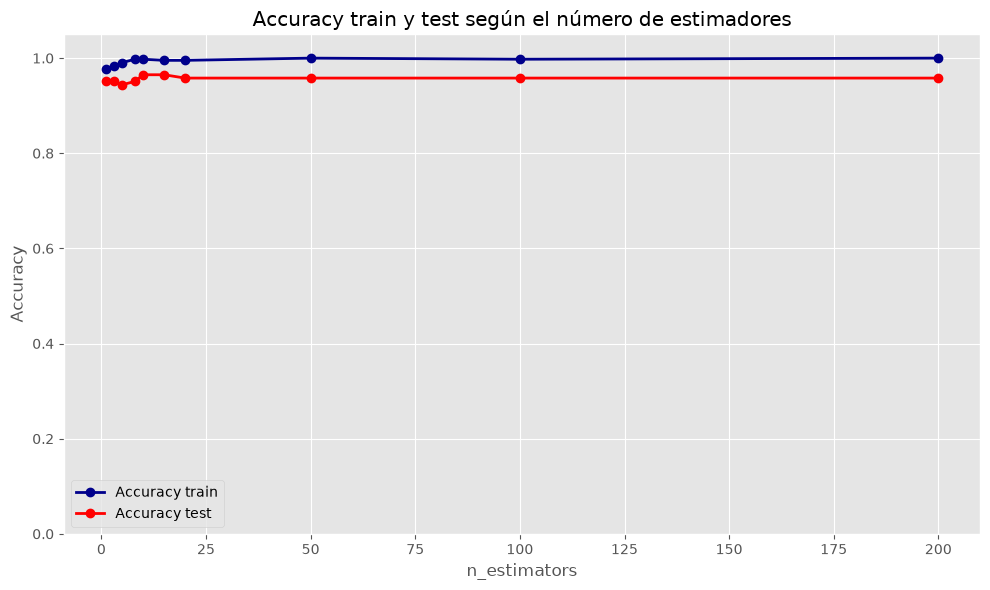

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(
    n_estimators_list,
    accuracy_train,
    marker="o",
    color="darkblue",
    linewidth=2,
    label="Accuracy train"
)
plt.plot(
    n_estimators_list,
    accuracy_test,
    marker="o",
    color="red",
    linewidth=2,
    label="Accuracy test"
)

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy train y test según el número de estimadores")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Importancia de variables en el modelo de bagging para clasificación

Aunque `BaggingClassifier` combina muchos árboles, cada árbol base conserva su propia medida de importancia de variables. Para obtener una importancia global del ensamble, se promedian las importancias de todos los árboles almacenados en `cancer_model.estimators_`. Es importante notar que `cancer_model` corresponde al último modelo ajustado dentro del ciclo anterior, es decir, al bagging con el mayor número de árboles evaluado (`n_estimators=200`). La gráfica resultante muestra qué características del conjunto Breast Cancer fueron más utilizadas, en promedio, para separar las clases del diagnóstico.


<Axes: xlabel='importance', ylabel='variable'>

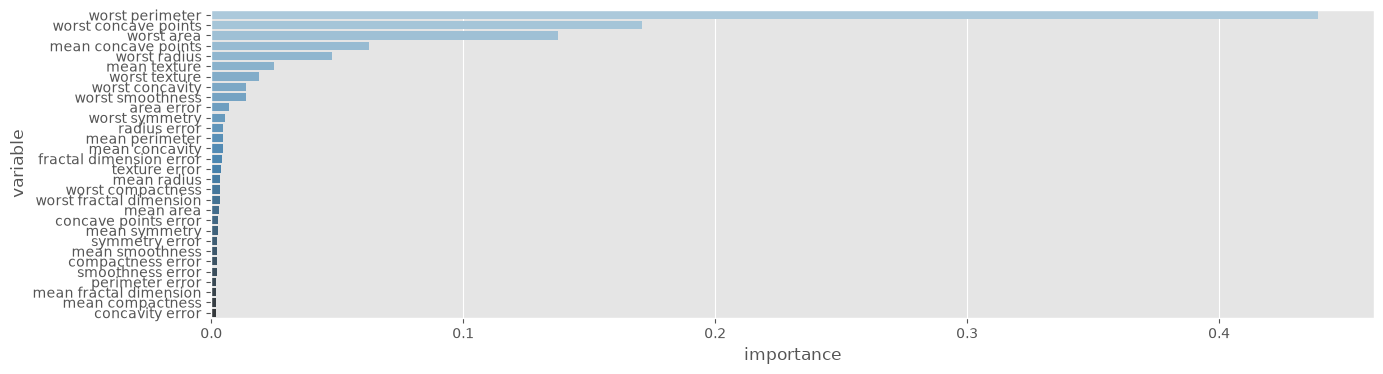

In [7]:
importances = np.mean(
    [tree.feature_importances_ for tree in cancer_model.estimators_],
    axis=0
)

importances_df = pd.DataFrame([X_train_cancer.columns,
                               importances])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)

plt.figure(figsize=(15,4))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")

___
#### Notebook 7.1.2 — Implementación: bagging en regresión
___

### Carga local del conjunto California Housing

El conjunto de datos **California Housing** contiene información recopilada durante el censo de California de 1990. Cada observación representa un grupo censal (*census block group*) e incluye variables demográficas y socioeconómicas relacionadas con las viviendas y sus habitantes.

El objetivo consiste en predecir el **valor mediano de las viviendas** a partir de diversas características de la zona, por lo que se trata de un problema de **regresión supervisada**.

### Información general

| Característica | Valor |
|----------------|-------|
| Tipo de problema | Regresión |
| Número de observaciones | 20,640 |
| Variables predictoras | 8 |
| Variable objetivo | 1 |

### Variables predictoras

| Variable | Descripción |
|----------|-------------|
| **MedInc** | Ingreso mediano de los hogares del grupo censal (expresado en decenas de miles de dólares). |
| **HouseAge** | Edad mediana de las viviendas (en años). |
| **AveRooms** | Número promedio de habitaciones por vivienda. |
| **AveBedrms** | Número promedio de dormitorios por vivienda. |
| **Population** | Número total de habitantes del grupo censal. |
| **AveOccup** | Número promedio de ocupantes por vivienda. |
| **Latitude** | Latitud geográfica del grupo censal. |
| **Longitude** | Longitud geográfica del grupo censal. |

### Variable objetivo

| Variable | Descripción |
|----------|-------------|
| **MedHouseVal** | Valor mediano de las viviendas del grupo censal, expresado en cientos de miles de dólares estadounidenses. |

### Observaciones

- Cada registro corresponde a un **grupo censal**, no a una vivienda individual.
- Las variables **Latitude** y **Longitude** permiten capturar la influencia de la ubicación geográfica sobre el precio de las viviendas.
- Este conjunto de datos es ampliamente utilizado para ilustrar técnicas de regresión y evaluación de modelos en aprendizaje automático.

In [8]:
data_paths = [Path("datos") / "california-housing.csv", Path("..") / "datos" / "california-housing.csv"]
data_path = next(path for path in data_paths if path.exists())

housing_data_df = pd.read_csv(data_path)
housing_feature_names = housing_data_df.drop(columns="MedHouseVal").columns.tolist()
housing_data_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### Separación entrenamiento-prueba para regresión

Para estudiar bagging en un problema de regresión, el conjunto California Housing se divide en una muestra de entrenamiento y una muestra de prueba. A diferencia del caso de clasificación, aquí la variable objetivo `MedHouseVal` es continua, por lo que no se usa estratificación. La separación permite ajustar el ensamble con los datos de entrenamiento y reservar observaciones no vistas para medir qué tan bien generaliza el modelo al predecir el valor medio de vivienda.


In [9]:
from sklearn.model_selection import train_test_split

X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(
    housing_data_df[housing_feature_names],
    housing_data_df["MedHouseVal"],
    test_size=0.25,
    random_state=123)

### Ajuste de bagging para árboles de regresión

En regresión, bagging combina varios árboles de regresión ajustados sobre muestras bootstrap del conjunto de entrenamiento. Cada árbol puede producir predicciones con alta variabilidad, pero al promediar las predicciones de muchos árboles el ensamble tiende a ser más estable. En esta celda se entrenan modelos con distintos valores de `n_estimators` y se registra el coeficiente de determinación $R^2$ en entrenamiento y prueba para analizar el efecto de aumentar el número de árboles.


In [10]:
from sklearn.metrics import r2_score
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

n_estimators_list = [1,3,5,8,10,15,20,50,100,200]

r2_train = []
r2_test = []

for n_estimators in n_estimators_list:
    housing_model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=43),
        n_estimators=n_estimators,
        bootstrap=True,
        random_state=43,
        n_jobs=-1).fit(X_train_housing, y_train_housing)
    
    y_train_pred = housing_model.predict(X_train_housing)
    y_test_pred = housing_model.predict(X_test_housing)
    r2_train.append(
        r2_score(y_train_housing, y_train_pred)
    )
    r2_test.append(
        r2_score(y_test_housing, y_test_pred)
    )

resultados = pd.DataFrame({
    "Número de árboles": n_estimators_list,
    "R2 entrenamiento": r2_train,
    "R2 prueba": r2_test
})
resultados

,Número de árboles,R2 entrenamiento,R2 prueba
0,1,0.846491,0.556166
1,3,0.929902,0.725737
2,5,0.948195,0.769235
3,8,0.958518,0.788826
4,10,0.961399,0.794844
5,15,0.966005,0.802579
6,20,0.968130,0.803873
7,50,0.971388,0.809353
8,100,0.972765,0.813473
9,200,0.973469,0.813663


### Evolución de R² al aumentar el número de árboles

La gráfica compara el $R^2$ de entrenamiento y prueba conforme cambia `n_estimators`. Un $R^2$ alto en entrenamiento y más bajo en prueba indica que el modelo ajusta muy bien los datos vistos, pero no necesariamente generaliza con la misma precisión. Al aumentar el número de árboles, el bagging suele reducir la variabilidad de las predicciones y estabilizar el desempeño fuera de muestra.


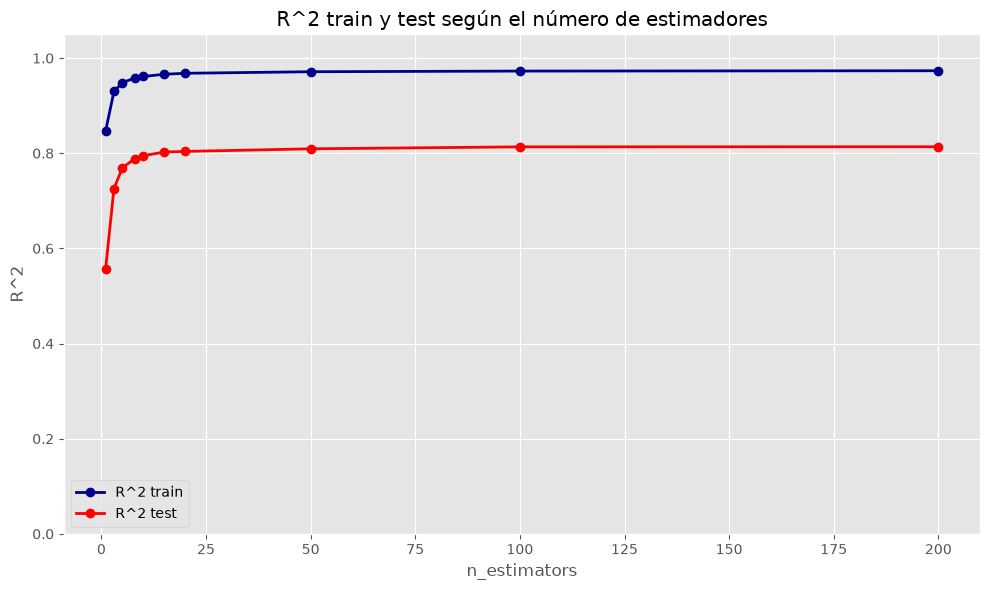

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(
    n_estimators_list,
    r2_train,
    marker="o",
    color="darkblue",
    linewidth=2,
    label="R^2 train"
)
plt.plot(
    n_estimators_list,
    r2_test,
    marker="o",
    color="red",
    linewidth=2,
    label="R^2 test"
)

plt.xlabel("n_estimators")
plt.ylabel("R^2")
plt.ylim(0, 1.05)
plt.title("R^2 train y test según el número de estimadores")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Importancia de variables en el modelo de bagging para regresión

De forma análoga al caso de clasificación, el `BaggingRegressor` no produce una única estructura de árbol, sino un conjunto de árboles de regresión ajustados sobre muestras bootstrap. Por ello, la importancia global de cada predictor se calcula promediando las importancias de los árboles contenidos en `housing_model.estimators_`. Como `housing_model` se actualiza en cada iteración del ciclo anterior, esta celda analiza el último modelo entrenado, correspondiente a `n_estimators=200`. La gráfica permite identificar qué variables del conjunto California Housing aportan más a la reducción promedio del error dentro del ensamble.


<Axes: xlabel='importance', ylabel='variable'>

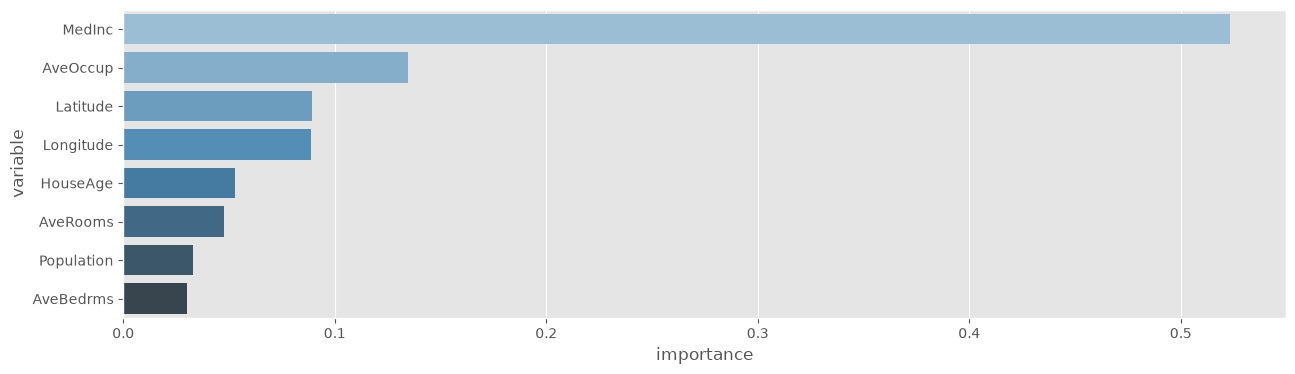

In [12]:
importances = np.mean(
    [tree.feature_importances_ for tree in housing_model.estimators_],
    axis=0
)

importances_df = pd.DataFrame([X_train_housing.columns,
                               importances])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)

plt.figure(figsize=(15,4))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")